## Import data and packages

In [39]:
import xarray as xr
import numpy as np
import xskillscore as xs
import scipy as sp
import pandas as pd
from scipy.optimize import least_squares
import statsmodels.api as sm
import matplotlib.pyplot as plt 
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import scipy.stats as stats

def smooth(var,twindow=15):
    temp = var.rolling(year=twindow,center=True).mean('year')
    return temp.where(temp.isnull()==False,drop=True)

def ME(x,y,a=None,b=None):  
    """  
    Compute the mean deviation of the data about the linear model given a, b (y=ax+b) provided as arguments. Otherwise, compute the mean deviation about the best-fit line.  
    x,y: 1-D array
    """
    if a==None:   
        # Performs linear regression; return a, b, rvalue (Pearson correlation coefficient), pvalue and standard error of a
        a, b, r, p, err = sp.stats.linregress(x,y)  
    
    # Std. deviation of an individual measurement 
    N = x.size
    return np.sqrt(np.sum((y-(a*x+b))**2)/(N-2))

def reg_conf(x, y, xin, a=None, b=None, conf=0.95):
    """
    Calculates the confidence band of the linear regression model at the desired confidence level
    - conf: desired confidence level, by default 0.95 (2 sigma)
    - x, y: data arrays
    - a,b: linear fit parameters as in y=ax+b
    - xin: x*, any input x value
  
    Returns:
    Sequence (xin, lc, uc) with the arrays holding the lower and upper confidence bands corresponding to the [input] x array.

    Usage: 
			xin, lc, uc = conf(x, y, a, b)
			ax.fill_between(xin,lc,uc, alpha=0.5, color='gainsboro')
    """
    alpha=1.-conf # significance
    N=x.size # data sample size
    if a==None:   
        # Performs linear regression; return a, b, rvalue (Pearson correlation coefficient), pvalue and standard error of a
        a, b, r, p, err = sp.stats.linregress(x,y) 
    # Predicted values (best-fit model)
    y_pre = a * xin + b
    s = ME(x, y, a, b)
    # Standard errors of the estimated means from the sample x
    SE = s*np.sqrt(1./N + (xin-x.mean())**2/np.sum((x-x.mean())**2))
    # Quantile of Student's t distribution for p=1-alpha/2
    t=sp.stats.t.ppf(1.-alpha/2.,N-2)
    # Confidence band
    dy=t*SE
    uc = y_pre + dy	# Upper confidence band
    lc = y_pre - dy	# Lower confidence band
    return xin, y_pre, lc, uc
    
fdir = '../../data/CESM2_clean_dataset/'
pic_dir = '../../output/figures/'
file_cmip_dir = '../../data/external/'

In [7]:
# CESM2-LE
exp = 'LE'
f = xr.open_mfdataset(fdir+'AMOCI/CESM2*'+exp+'_AMOC40_ts*.nc',combine='by_coords')
amoc_le = f[list(f.data_vars)[0]].load()
f = xr.open_dataset(fdir+'SSTand/CESM2-'+exp+'_WHI_full.nc')
whi_le = f[list(f.data_vars)[0]]
    
# Load CMIP6 historical + ssp585 data
whi_cmip6 = {}
amoc_cmip6 = {}
late8models = ['GFDL-ESM4','CESM2','MPI-ESM1-2-LR','CESM2-WACCM','NorESM2-MM','MRI-ESM2-0','GISS-E2-1-G','GISS-E2-2-G']
early7models = ['CMCC-CM2-SR5','CMCC-ESM2','MPI-ESM1-2-HR','MIROC6','GFDL-CM4','HadGEM3-GC31-MM','NorESM2-LM']
models = early7models + late8models
for m in models:
    print(m)
    amoc_cmip6[m] = xr.open_dataset(file_cmip_dir+m+'_historical+ssp585_AMOC40_r1.nc')['AMOC']
    whi_cmip6[m] = xr.open_dataset(file_cmip_dir+m+'_historical+ssp585_WHI_r1.nc')['WHI']

CMCC-CM2-SR5
CMCC-ESM2
MPI-ESM1-2-HR
MIROC6
GFDL-CM4
HadGEM3-GC31-MM
NorESM2-LM
GFDL-ESM4
CESM2
MPI-ESM1-2-LR
CESM2-WACCM
NorESM2-MM
MRI-ESM2-0
GISS-E2-1-G
GISS-E2-2-G


In [8]:
amoc_cmip6_da = xr.concat(amoc_cmip6.values(), dim="model")
amoc_cmip6_da = amoc_cmip6_da.assign_coords(model=models)
whi_cmip6_da = xr.concat(whi_cmip6.values(), dim="model")
whi_cmip6_da = whi_cmip6_da.assign_coords(model=models)
moving_s_cmip6 = amoc_cmip6_da.rename('sensitivity').copy()
moving_amoc_mean_cmip6 = amoc_cmip6_da.rename('mean_AMOC').copy()

moving_s_le = amoc_le.rename('sensitivity').copy()
moving_amoc_mean_le = amoc_le.rename('mean_AMOC').copy()

## Calculate moving sensitivity, moving average AMOCI,  maximum sensitivity, and corresponding AMOCI and time

In [28]:
def linear_fit(x,y):
    if np.isnan(x).any():
        return np.nan
    slope, _ = np.polyfit(x, y, 1)    
    return slope
 
def mean_func(x):
    if np.isnan(x).any():
        return np.nan  
    return np.mean(x)

def moving_sensitivity(whi, amoc, window=40, smooth_window=15):
    if (smooth_window>0):
        whi = whi.rolling(year=smooth_window, center=True).mean('year')
        amoc = amoc.rolling(year=smooth_window, center=True).mean('year')
    rolling_whi = whi.rolling(year=window, center=True).construct('window_dim')
    rolling_amoc = amoc.rolling(year=window, center=True).construct('window_dim')
    # Moving sensitivity -> linear regression 
    ms = xr.apply_ufunc(linear_fit, rolling_amoc, rolling_whi, input_core_dims=[["window_dim"], ["window_dim"]],
                        vectorize=True, dask="parallelized",  # Optional: if using dask
                        output_dtypes=[float])
    # Moving AMOC mean state
    amoc_mean = xr.apply_ufunc(mean_func, rolling_amoc, input_core_dims=[["window_dim"]],
                               vectorize=True, dask="parallelized",  # Optional: if using dask
                               output_dtypes=[float])
    return ms, amoc_mean

n_point = 15 # parameter to change the weight of smoothing; 15-point smoothing
weights = np.ones(n_point) / n_point

max_s_cmip6 = np.zeros(len(models))       # the maximum sensitivity values 
max_s_amoc_cmip6 = np.zeros(len(models))  # the mean-state AMOC corresponding to maximum sensitivity 
max_s_year_cmip6 = np.zeros(len(models))  # the year corresponding to maximum sensitivity 
years = moving_amoc_mean_cmip6.year.values

for i in range(len(models)):
    m = models[i]
    moving_s_cmip6[i,:], moving_amoc_mean_cmip6[i,:] = moving_sensitivity(whi_cmip6_da[i,:], amoc_cmip6_da[i,:])

    # Find the maximum sensitivity 
    ## first, sort the sensitivity in the order of AMOC states
    ## then, apply 15-point smoothing the sensitivity
    x = moving_amoc_mean_cmip6[i,-100:].values # only years 2000-2100 
    y = moving_s_cmip6[i,-100:].values
    x_sort = np.sort(x)
    y_sort = y[np.argsort(x)] 
    x_sort = np.convolve(x_sort, weights, mode='valid')
    y_sort = np.convolve(y_sort, weights, mode='valid')
    max_s_cmip6[i] = np.nanmax(y_sort)
    max_s_amoc_cmip6[i] = x_sort[np.nanargmax(y_sort)]  
    
    # Find the corresponding year --> the first year when the AMOC is weaker than the AMOCI corresponding to the maximum sensitivity
    amoc_id = np.where(moving_amoc_mean_cmip6[i,:] < max_s_amoc_cmip6[i])[0][0]
    max_s_year_cmip6[i] = years[amoc_id]
print(max_s_year_cmip6)

for i in range(100):
    moving_s_le[i,:], moving_amoc_mean_le[i,:] = moving_sensitivity(whi_le[i,:], amoc_le[i,:])

[2021. 2022. 2022. 2027. 2032. 2036. 2038. 2043. 2047. 2049. 2058. 2059.
 2065. 2066. 2067.]


## Plotting
Fig. 4a

/glade/derecho/scratch/fyifei/tmp/ipykernel_49408/2992821129.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_all = plt.cm.get_cmap('jet', len(models))
/glade/derecho/scratch/fyifei/tmp/ipykernel_49408/2992821129.py:33: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(max_s_amoc_cmip6[i], max_s_cmip6[i], c=colors_all(i), marker='o',s=50,zorder=3, edgecolor='k',alpha=1,lw=0.6,
/glade/derecho/scratch/fyifei/tmp/ipykernel_49408/2992821129.py:35: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequ

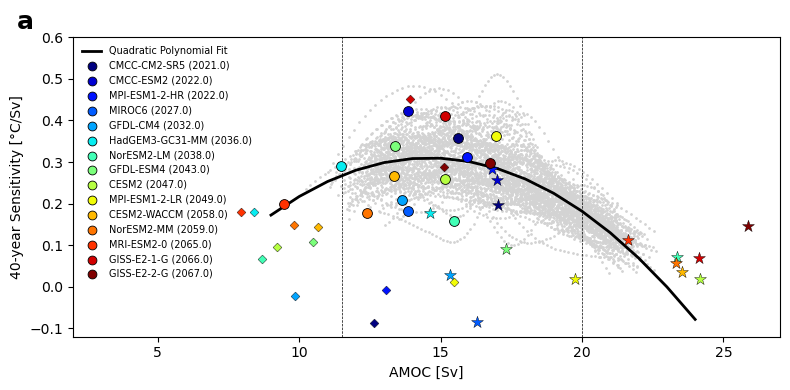

In [42]:
all_x_sort = []
all_y_sort = []

fig = plt.subplots(1,1,figsize=(8, 4))
colors_all = plt.cm.get_cmap('jet', len(models))
plt.axvline(x=11.5, ls='--',c='k',lw=0.5)
plt.axvline(x=20, ls='--',c='k',lw=0.5)

for i in range(100):
    x = moving_amoc_mean_le[i,-100:].values # only plotting years 2000-2099
    y = moving_s_le[i,-100:].values 
    x_sort = np.sort(x)
    y_sort = y[np.argsort(x)] 
    x_sort = np.convolve(x_sort, weights, mode='valid')
    y_sort = np.convolve(y_sort, weights, mode='valid')
    all_x_sort.extend(x_sort)
    all_y_sort.extend(y_sort)

all_x_sort = np.array(all_x_sort)
all_y_sort = np.array(all_y_sort)
all_x_sort = all_x_sort[~np.isnan(all_x_sort)]
all_y_sort = all_y_sort[~np.isnan(all_y_sort)]
plt.scatter(all_x_sort, all_y_sort, color='lightgrey',s=1,zorder=1)
## Plot Quadratic Polynomial Fit
y_fit = np.polyfit(all_x_sort, all_y_sort, 2)
poly_fit_func = np.poly1d(y_fit)
plt.plot(np.arange(9,25),poly_fit_func(np.arange(9,25)),lw=2,c='k',label='Quadratic Polynomial Fit')

for i in range(len(models)):
    m = models[i]
    x = moving_amoc_mean_cmip6[i,-100:].values # only keep 2000-2099
    y = moving_s_cmip6[i,-100:].values
    plt.scatter(max_s_amoc_cmip6[i], max_s_cmip6[i], c=colors_all(i), marker='o',s=50,zorder=3, edgecolor='k',alpha=1,lw=0.6,
                label=m+' ('+str(max_s_year_cmip6[i])+')')
    plt.scatter(x[0],y[0], c=colors_all(i), marker='*',zorder=3, edgecolor='k',alpha=1,lw=0.3,s=80) # 1980-2020
    plt.scatter(x[-27],y[-27], c=colors_all(i), marker='D',zorder=3, edgecolor='k',alpha=1,lw=0.3,s=20) # 2053–2093

plt.legend(ncol=1,fontsize=7, markerscale=0.9, loc='upper left',frameon=False) #
plt.ylim(-0.12,0.6)
plt.xlim(2,27)
plt.xlabel('AMOC [Sv]')
plt.ylabel('40-year Sensitivity [\u00B0C/Sv]')
plt.title('a',loc='left',fontdict={'weight': 'bold', 'size': 18},x=-0.08)
plt.tight_layout()
plt.savefig(pic_dir+'Fig4a_smooth_sensitivity_15point_avg_scatter.pdf')
plt.show()

In [27]:
# regression 
whi_cmip6_da_ano = smooth(whi_cmip6_da - whi_cmip6_da[:,150:160].mean('year'), 15)
y_whsst = (whi_cmip6_da[:,-10:].mean('year') - whi_cmip6_da[:,150:160].mean('year')).values
res = sm.OLS(y_whsst, sm.add_constant(max_s_year_cmip6)).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.787
Method:                 Least Squares   F-statistic:                     52.67
Date:                Mon, 11 May 2026   Prob (F-statistic):           6.39e-06
Time:                        11:22:50   Log-Likelihood:                -11.002
No. Observations:                  15   AIC:                             26.00
Df Residuals:                      13   BIC:                             27.42
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        126.2480     17.630      7.161      0.0

/glade/derecho/scratch/fyifei/tmp/ipykernel_49408/1004806803.py:4: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[0].scatter(max_s_year_cmip6[i], y_whsst[i], c=colors_all(i), edgecolor='k',alpha=1,lw=0.6,s=50)


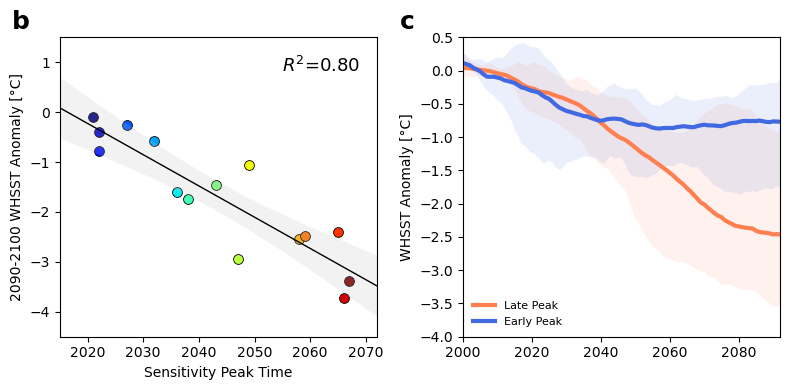

In [40]:
# Fig. 4b and 4c
fig, axs = plt.subplots(1,2,figsize=(8, 4))
for i in range(len(models)):
    axs[0].scatter(max_s_year_cmip6[i], y_whsst[i], c=colors_all(i), edgecolor='k',alpha=1,lw=0.6,s=50)
axs[1].fill_between(whi_cmip6_da_ano.year, 
                 whi_cmip6_da_ano.sel(model=late8models).min('model'),
                 whi_cmip6_da_ano.sel(model=late8models).max('model'),alpha=0.1,fc='coral')
axs[1].fill_between(whi_cmip6_da_ano.year, 
                 whi_cmip6_da_ano.sel(model=early7models).min('model'),
                 whi_cmip6_da_ano.sel(model=early7models).max('model'),alpha=0.1,fc='royalblue')
(whi_cmip6_da_ano.sel(model=late8models).mean('model')).plot(ax=axs[1],label='Late Peak',c='coral',lw=3)
(whi_cmip6_da_ano.sel(model=early7models).mean('model')).plot(ax=axs[1],label='Early Peak',c='royalblue',lw=3)
axs[1].legend(loc='lower left',fontsize=8,frameon=False)
axs[1].set_xlim(2000,2092)
axs[1].set_ylim(-4,0.5)
axs[1].set_xlabel('')
axs[1].set_ylabel('WHSST Anomaly [\u00B0C]')
axs[1].set_title('c',loc='left',fontdict={'weight': 'bold', 'size': 18},x=-0.2)

xin, ypre, y_lower, y_upper = reg_conf(max_s_year_cmip6, y_whsst, np.arange(2000,2100))
axs[0].plot(xin, ypre, c='k',lw=1)
axs[0].fill_between(xin, y_lower, y_upper, fc='silver',alpha=0.2)
axs[0].set_title('b',loc='left',fontdict={'weight': 'bold', 'size': 18},x=-0.15)
axs[0].set_xlabel('Sensitivity Peak Time')
axs[0].set_ylabel('2090-2100 WHSST Anomaly [\u00B0C]')
axs[0].set_xlim(2015,2072)
axs[0].set_ylim(-4.5,1.5)
axs[0].text(2055, .8, f"$R^2$={res.rsquared:.2f}",fontsize=13)
plt.tight_layout()
plt.savefig(pic_dir+'Fig4b&c_smooth_WHSST_avg.pdf')
plt.show()